# Phase 6 — Hyperparameter Tuning and Final Model Evaluation

This notebook tunes the strongest baseline models identified during Phase 5, compares the tuned configurations, selects the final classifier, evaluates it on the untouched test dataset, and prepares the fitted pipeline for deployment.

## Objectives

- Reproduce the exact training, validation, and test splits used during baseline modelling.
- Preserve the test dataset until final model selection.
- Tune the strongest baseline models using stratified cross-validation.
- Use Macro F1 as the primary optimisation metric.
- Compare tuned models against their baseline counterparts.
- Select and refit the final machine-learning pipeline.
- Perform one final evaluation using the untouched test set.
- Save the fitted preprocessing and prediction pipeline for application use.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)

In [2]:
current_path = Path.cwd().resolve()

PROJECT_ROOT = None

for candidate in [
    current_path,
    *current_path.parents,
]:
    preprocessing_path = (
        candidate
        / "src"
        / "preprocessing.py"
    )

    if preprocessing_path.exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root"
    )

print(
    "Project root:",
    PROJECT_ROOT,
)

Project root: C:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System


In [3]:
project_root_string = str(
    PROJECT_ROOT
)

if project_root_string not in sys.path:
    sys.path.insert(
        0,
        project_root_string,
    )

In [4]:
from src.preprocessing import (
    PREDICTIVE_FEATURES,
    build_preprocessor,
)

In [5]:
print(
    "Number of predictive features:",
    len(PREDICTIVE_FEATURES),
)

print(
    "Predictive features:"
)

for feature in PREDICTIVE_FEATURES:
    print("-", feature)

Number of predictive features: 16
Predictive features:
- Age
- Height
- Weight
- FCVC
- NCP
- CH2O
- FAF
- TUE
- CAEC
- CALC
- Gender
- family_history_with_overweight
- FAVC
- SMOKE
- SCC
- MTRANS


In [6]:
preprocessor_check = build_preprocessor()

print(
    "Preprocessor type:",
    type(preprocessor_check).__name__,
)

Preprocessor type: ColumnTransformer


In [7]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "obesity.csv"
)

BASELINE_REPORT_PATH = (
    PROJECT_ROOT
    / "reports"
    / "generated"
    / "baseline_model_comparison.csv"
)

TUNING_CANDIDATES_PATH = (
    PROJECT_ROOT
    / "reports"
    / "generated"
    / "tuning_candidates.csv"
)

print("Dataset:", DATA_PATH)
print("Baseline report:", BASELINE_REPORT_PATH)
print(
    "Tuning candidates:",
    TUNING_CANDIDATES_PATH,
)

Dataset: C:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\data\raw\obesity.csv
Baseline report: C:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\reports\generated\baseline_model_comparison.csv
Tuning candidates: C:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\reports\generated\tuning_candidates.csv


In [8]:
assert DATA_PATH.exists(), (
    f"Dataset not found: {DATA_PATH}"
)

assert BASELINE_REPORT_PATH.exists(), (
    "Baseline comparison report was not found"
)

assert TUNING_CANDIDATES_PATH.exists(), (
    "Tuning candidates report was not found"
)

print(
    "All required Phase 6 input files exist"
)

All required Phase 6 input files exist


In [9]:
IDENTIFIER_COLUMN = "id"
TARGET_COLUMN = "NObeyesdad"
RANDOM_STATE = 42

In [10]:
CLASS_ORDER = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

In [11]:
df = pd.read_csv(
    DATA_PATH
)

print(
    "Dataset shape:",
    df.shape,
)

df.head()

Dataset shape: (20758, 18)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [12]:
print(
    "Number of rows:",
    len(df),
)

print(
    "Number of columns:",
    len(df.columns),
)

print(
    "Target classes:",
    df[TARGET_COLUMN].nunique(),
)

Number of rows: 20758
Number of columns: 18
Target classes: 7


In [13]:
X = df[
    PREDICTIVE_FEATURES
].copy()

y = df[
    TARGET_COLUMN
].copy()

print(
    "Feature matrix shape:",
    X.shape,
)

print(
    "Target shape:",
    y.shape,
)

Feature matrix shape: (20758, 16)
Target shape: (20758,)


In [14]:
assert list(
    X.columns
) == PREDICTIVE_FEATURES

assert len(
    X.columns
) == 16

assert len(
    X
) == len(
    y
)

print(
    "Feature configuration verified"
)

Feature configuration verified


In [15]:
X_train, X_temp, y_train, y_temp = (
    train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y,
    )
)

In [16]:
X_validation, X_test, y_validation, y_test = (
    train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=y_temp,
    )
)

In [17]:
split_summary_df = pd.DataFrame(
    {
        "Dataset": [
            "Training",
            "Validation",
            "Test",
        ],
        "Records": [
            len(X_train),
            len(X_validation),
            len(X_test),
        ],
        "Percentage": [
            len(X_train) / len(X) * 100,
            len(X_validation) / len(X) * 100,
            len(X_test) / len(X) * 100,
        ],
    }
)

split_summary_df.round(2)

,Dataset,Records,Percentage
0,Training,14530,70.0
1,Validation,3114,15.0
2,Test,3114,15.0


In [18]:
train_validation_overlap = (
    X_train.index
    .intersection(
        X_validation.index
    )
)

train_test_overlap = (
    X_train.index
    .intersection(
        X_test.index
    )
)

validation_test_overlap = (
    X_validation.index
    .intersection(
        X_test.index
    )
)

print(
    "Train-validation overlap:",
    len(train_validation_overlap),
)

print(
    "Train-test overlap:",
    len(train_test_overlap),
)

print(
    "Validation-test overlap:",
    len(validation_test_overlap),
)

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0


In [19]:
class_distribution_df = pd.DataFrame(
    {
        "Full Dataset": (
            y.value_counts(
                normalize=True
            )
        ),
        "Training": (
            y_train.value_counts(
                normalize=True
            )
        ),
        "Validation": (
            y_validation.value_counts(
                normalize=True
            )
        ),
        "Test": (
            y_test.value_counts(
                normalize=True
            )
        ),
    }
).reindex(CLASS_ORDER)

class_distribution_df.round(4)

,Full Dataset,Training,Validation,Test
NObeyesdad,,,,
Insufficient_Weight,0.1215,0.1215,0.1217,0.1214
Normal_Weight,0.1485,0.1485,0.1487,0.1484
Overweight_Level_I,0.1169,0.1169,0.1169,0.1169
Overweight_Level_II,0.1215,0.1215,0.1214,0.1217
Obesity_Type_I,0.1402,0.1402,0.1400,0.1403
Obesity_Type_II,0.1565,0.1565,0.1564,0.1564
Obesity_Type_III,0.1949,0.1949,0.1949,0.1949


In [20]:
baseline_results_df = pd.read_csv(
    BASELINE_REPORT_PATH
)

baseline_results_df

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro F1 Rank,Balanced Accuracy Rank,Accuracy Rank
0,Gradient Boosting,0.903340,0.893142,0.893031,0.902952,1,1,1
1,Random Forest,0.895633,0.884543,0.884858,0.895254,2,2,2
2,Logistic Regression,0.858060,0.843242,0.841809,0.856599,3,3,3
3,Decision Tree,0.845215,0.831168,0.830801,0.845645,4,4,4
4,Dummy Classifier,0.194926,0.142857,0.046608,0.063596,5,5,5


In [21]:
tuning_candidates_df = pd.read_csv(
    TUNING_CANDIDATES_PATH
)

tuning_candidates_df

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Training Macro F1,Macro F1 Gap
0,Gradient Boosting,0.903340,0.893142,0.893031,0.902952,0.912625,0.019594
1,Random Forest,0.895633,0.884543,0.884858,0.895254,1.000000,0.115142


In [22]:
tuning_candidate_names = (
    tuning_candidates_df[
        "Model"
    ]
    .tolist()
)

print(
    "Models selected for tuning:"
)

for model_number, model_name in enumerate(
    tuning_candidate_names,
    start=1,
):
    print(
        f"{model_number}. {model_name}"
    )

Models selected for tuning:
1. Gradient Boosting
2. Random Forest


In [23]:
assert len(
    tuning_candidate_names
) == 2

assert set(
    tuning_candidate_names
) == {
    "Gradient Boosting",
    "Random Forest",
}

print(
    "Phase 5 tuning candidates verified"
)

Phase 5 tuning candidates verified


In [24]:
baseline_results_lookup = (
    baseline_results_df
    .set_index("Model")
)

gradient_boosting_baseline_macro_f1 = (
    baseline_results_lookup.loc[
        "Gradient Boosting",
        "Macro F1",
    ]
)

random_forest_baseline_macro_f1 = (
    baseline_results_lookup.loc[
        "Random Forest",
        "Macro F1",
    ]
)

print(
    "Gradient Boosting baseline Macro F1:",
    round(
        gradient_boosting_baseline_macro_f1,
        4,
    ),
)

print(
    "Random Forest baseline Macro F1:",
    round(
        random_forest_baseline_macro_f1,
        4,
    ),
)

Gradient Boosting baseline Macro F1: 0.893
Random Forest baseline Macro F1: 0.8849


In [25]:
development_summary = {
    "Total records": len(X),
    "Training records": len(X_train),
    "Validation records": len(X_validation),
    "Reserved test records": len(X_test),
    "Predictive features": len(PREDICTIVE_FEATURES),
    "Target classes": y.nunique(),
    "Tuning candidates": len(
        tuning_candidate_names
    ),
}

pd.Series(
    development_summary,
    name="Value",
)

Total records            20758
Training records         14530
Validation records        3114
Reserved test records     3114
Predictive features         16
Target classes               7
Tuning candidates            2
Name: Value, dtype: int64

In [26]:
assert df.shape == (
    20758,
    18,
)

assert X.shape == (
    20758,
    16,
)

assert len(y) == 20758

assert len(X_train) == 14530
assert len(X_validation) == 3114
assert len(X_test) == 3114

assert len(y_train) == 14530
assert len(y_validation) == 3114
assert len(y_test) == 3114

assert len(
    train_validation_overlap
) == 0

assert len(
    train_test_overlap
) == 0

assert len(
    validation_test_overlap
) == 0

assert y.nunique() == 7

assert len(
    tuning_candidate_names
) == 2

assert set(
    tuning_candidate_names
) == {
    "Gradient Boosting",
    "Random Forest",
}

In [27]:
N_CV_SPLITS = 5

cross_validation = StratifiedKFold(
    n_splits=N_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cross_validation

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [28]:
number_of_cv_splits = (
    cross_validation.get_n_splits(
        X_train,
        y_train,
    )
)

print(
    "Number of cross-validation folds:",
    number_of_cv_splits,
)

Number of cross-validation folds: 5


In [29]:
cv_fold_summary = []

for fold_number, (
    fold_train_indices,
    fold_validation_indices,
) in enumerate(
    cross_validation.split(
        X_train,
        y_train,
    ),
    start=1,
):
    cv_fold_summary.append(
        {
            "Fold": fold_number,
            "Training Records": len(
                fold_train_indices
            ),
            "Validation Records": len(
                fold_validation_indices
            ),
        }
    )

cv_fold_summary_df = pd.DataFrame(
    cv_fold_summary
)

cv_fold_summary_df

,Fold,Training Records,Validation Records
0,1,11624,2906
1,2,11624,2906
2,3,11624,2906
3,4,11624,2906
4,5,11624,2906


In [30]:
cv_class_distribution_records = []

for fold_number, (
    _,
    fold_validation_indices,
) in enumerate(
    cross_validation.split(
        X_train,
        y_train,
    ),
    start=1,
):
    fold_targets = y_train.iloc[
        fold_validation_indices
    ]

    fold_distribution = (
        fold_targets
        .value_counts(normalize=True)
        .reindex(CLASS_ORDER)
    )

    for class_name, proportion in (
        fold_distribution.items()
    ):
        cv_class_distribution_records.append(
            {
                "Fold": fold_number,
                "Class": class_name,
                "Proportion": proportion,
            }
        )

cv_class_distribution_df = pd.DataFrame(
    cv_class_distribution_records
)

cv_distribution_pivot = (
    cv_class_distribution_df
    .pivot(
        index="Class",
        columns="Fold",
        values="Proportion",
    )
    .reindex(CLASS_ORDER)
)

cv_distribution_pivot.round(4)

Fold,1,2,3,4,5
Class,,,,,
Insufficient_Weight,0.1215,0.1215,0.1215,0.1215,0.1218
Normal_Weight,0.1483,0.1483,0.1487,0.1487,0.1483
Overweight_Level_I,0.1170,0.1170,0.1167,0.1170,0.1170
Overweight_Level_II,0.1215,0.1215,0.1215,0.1215,0.1215
Obesity_Type_I,0.1401,0.1404,0.1404,0.1401,0.1401
Obesity_Type_II,0.1566,0.1562,0.1566,0.1566,0.1566
Obesity_Type_III,0.1951,0.1951,0.1948,0.1948,0.1948


In [31]:
SCORING_METRICS = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}

SCORING_METRICS

{'accuracy': 'accuracy',
 'balanced_accuracy': 'balanced_accuracy',
 'macro_f1': 'f1_macro',
 'weighted_f1': 'f1_weighted'}

In [32]:
PRIMARY_SCORING_METRIC = "macro_f1"

print(
    "Primary tuning metric:",
    PRIMARY_SCORING_METRIC,
)

Primary tuning metric: macro_f1


In [33]:
SEARCH_ITERATIONS = 20

SEARCH_CONFIGURATION = {
    "n_iter": SEARCH_ITERATIONS,
    "scoring": SCORING_METRICS,
    "refit": PRIMARY_SCORING_METRIC,
    "cv": cross_validation,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": 1,
    "return_train_score": True,
}

SEARCH_CONFIGURATION

{'n_iter': 20,
 'scoring': {'accuracy': 'accuracy',
  'balanced_accuracy': 'balanced_accuracy',
  'macro_f1': 'f1_macro',
  'weighted_f1': 'f1_weighted'},
 'refit': 'macro_f1',
 'cv': StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
 'random_state': 42,
 'n_jobs': -1,
 'verbose': 1,
 'return_train_score': True}

In [34]:
fits_per_model = (
    SEARCH_ITERATIONS
    * N_CV_SPLITS
)

total_expected_cv_fits = (
    fits_per_model
    * len(tuning_candidate_names)
)

print(
    "Configurations per model:",
    SEARCH_ITERATIONS,
)

print(
    "CV folds:",
    N_CV_SPLITS,
)

print(
    "Expected fits per model:",
    fits_per_model,
)

print(
    "Expected fits across two models:",
    total_expected_cv_fits,
)

Configurations per model: 20
CV folds: 5
Expected fits per model: 100
Expected fits across two models: 200


In [35]:
print(
    "Training records used for tuning:",
    len(X_train),
)

print(
    "External validation records:",
    len(X_validation),
)

print(
    "Reserved test records:",
    len(X_test),
)

Training records used for tuning: 14530
External validation records: 3114
Reserved test records: 3114


In [36]:
assert N_CV_SPLITS == 5

assert (
    cross_validation.get_n_splits(
        X_train,
        y_train,
    )
    == 5
)

assert set(
    SCORING_METRICS.keys()
) == {
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
}

assert (
    PRIMARY_SCORING_METRIC
    in SCORING_METRICS
)

assert SEARCH_ITERATIONS == 20

assert fits_per_model == 100

assert total_expected_cv_fits == 200

assert len(X_train) == 14530
assert len(X_validation) == 3114
assert len(X_test) == 3114

In [37]:
random_forest_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            build_preprocessor(),
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)

random_forest_tuning_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [38]:
random_forest_parameter_space = {
    "classifier__n_estimators": [
        150,
        200,
        300,
        400,
    ],
    "classifier__max_depth": [
        None,
        10,
        15,
        20,
        30,
    ],
    "classifier__min_samples_split": [
        2,
        5,
        10,
    ],
    "classifier__min_samples_leaf": [
        1,
        2,
        4,
    ],
    "classifier__max_features": [
        "sqrt",
        "log2",
        0.5,
    ],
    "classifier__class_weight": [
        None,
        "balanced",
        "balanced_subsample",
    ],
}

random_forest_parameter_space

{'classifier__n_estimators': [150, 200, 300, 400],
 'classifier__max_depth': [None, 10, 15, 20, 30],
 'classifier__min_samples_split': [2, 5, 10],
 'classifier__min_samples_leaf': [1, 2, 4],
 'classifier__max_features': ['sqrt', 'log2', 0.5],
 'classifier__class_weight': [None, 'balanced', 'balanced_subsample']}

In [39]:
random_forest_search_space_size = (
    len(
        random_forest_parameter_space[
            "classifier__n_estimators"
        ]
    )
    * len(
        random_forest_parameter_space[
            "classifier__max_depth"
        ]
    )
    * len(
        random_forest_parameter_space[
            "classifier__min_samples_split"
        ]
    )
    * len(
        random_forest_parameter_space[
            "classifier__min_samples_leaf"
        ]
    )
    * len(
        random_forest_parameter_space[
            "classifier__max_features"
        ]
    )
    * len(
        random_forest_parameter_space[
            "classifier__class_weight"
        ]
    )
)

print(
    "Possible Random Forest combinations:",
    random_forest_search_space_size,
)

print(
    "Random combinations to evaluate:",
    SEARCH_ITERATIONS,
)

Possible Random Forest combinations: 1620
Random combinations to evaluate: 20


In [40]:
random_forest_search = RandomizedSearchCV(
    estimator=random_forest_tuning_pipeline,
    param_distributions=(
        random_forest_parameter_space
    ),
    **SEARCH_CONFIGURATION,
)

random_forest_search

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__class_weight': [None, 'balanced', ...], 'classifier__max_depth': [None, 10, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'macro_f1': 'f1_macro', 'weighted_f1': 'f1_weighted'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'macro_f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. The

In [41]:
random_forest_search.fit(
    X_train,
    y_train,
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__class_weight': [None, 'balanced', ...], 'classifier__max_depth': [None, 10, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'macro_f1': 'f1_macro', 'weighted_f1': 'f1_weighted'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'macro_f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. The

In [42]:
random_forest_best_cv_macro_f1 = (
    random_forest_search.best_score_
)

print(
    "Best Random Forest CV Macro F1:",
    round(
        random_forest_best_cv_macro_f1,
        4,
    ),
)

Best Random Forest CV Macro F1: 0.8872


In [43]:
random_forest_best_parameters = (
    random_forest_search.best_params_
)

print(
    "Best Random Forest hyperparameters:"
)

for parameter, value in (
    random_forest_best_parameters.items()
):
    print(
        f"{parameter}: {value}"
    )

Best Random Forest hyperparameters:
classifier__n_estimators: 150
classifier__min_samples_split: 10
classifier__min_samples_leaf: 2
classifier__max_features: 0.5
classifier__max_depth: 20
classifier__class_weight: None


In [44]:
tuned_random_forest_pipeline = (
    random_forest_search.best_estimator_
)

tuned_random_forest_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [45]:
random_forest_cv_results_df = (
    pd.DataFrame(
        random_forest_search.cv_results_
    )
)

print(
    "Configurations evaluated:",
    len(random_forest_cv_results_df),
)

Configurations evaluated: 20


In [46]:
random_forest_tuning_summary_df = (
    random_forest_cv_results_df[
        [
            "rank_test_macro_f1",
            "mean_test_macro_f1",
            "std_test_macro_f1",
            "mean_train_macro_f1",
            "mean_test_accuracy",
            "mean_test_balanced_accuracy",
            "mean_test_weighted_f1",
            "mean_fit_time",
            "param_classifier__n_estimators",
            "param_classifier__max_depth",
            "param_classifier__min_samples_split",
            "param_classifier__min_samples_leaf",
            "param_classifier__max_features",
            "param_classifier__class_weight",
        ]
    ]
    .sort_values(
        by="rank_test_macro_f1"
    )
    .reset_index(drop=True)
)

random_forest_tuning_summary_df.head(10)

,rank_test_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_train_macro_f1,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_weighted_f1,mean_fit_time,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__max_features,param_classifier__class_weight
0,1,0.887195,0.006269,0.945690,0.898348,0.887002,0.898087,6.235763,150,20,10,2,0.5,NaN
1,2,0.886963,0.007043,0.961480,0.897935,0.886987,0.897839,6.180466,150,15,5,2,0.5,balanced
2,3,0.886837,0.005373,0.990737,0.898004,0.886655,0.897763,6.697029,200,15,2,1,0.5,NaN
3,4,0.886473,0.005926,0.973483,0.897591,0.886496,0.897428,8.452951,200,None,2,2,0.5,balanced_subsample
4,5,0.886214,0.006193,0.984819,0.897385,0.886230,0.897230,8.747589,200,30,5,1,0.5,balanced_subsample
5,6,0.886116,0.005648,0.955806,0.897109,0.886204,0.897034,6.173126,150,None,10,1,0.5,balanced
6,7,0.885899,0.006474,0.985111,0.897041,0.885892,0.896881,12.836114,300,30,5,1,0.5,balanced_subsample
7,8,0.882728,0.006944,0.987813,0.894494,0.882202,0.894250,10.160665,400,15,2,1,sqrt,balanced
8,9,0.881169,0.006762,0.971862,0.892842,0.880924,0.892718,3.601803,150,None,2,2,sqrt,balanced
9,10,0.880857,0.007010,0.937826,0.892429,0.880810,0.892253,7.705051,400,None,2,4,sqrt,balanced


In [47]:
best_random_forest_cv_row = (
    random_forest_tuning_summary_df.iloc[0]
)

random_forest_cv_train_macro_f1 = (
    best_random_forest_cv_row[
        "mean_train_macro_f1"
    ]
)

random_forest_cv_validation_macro_f1 = (
    best_random_forest_cv_row[
        "mean_test_macro_f1"
    ]
)

random_forest_cv_macro_f1_gap = (
    random_forest_cv_train_macro_f1
    - random_forest_cv_validation_macro_f1
)

print(
    "Mean CV training Macro F1:",
    round(
        random_forest_cv_train_macro_f1,
        4,
    ),
)

print(
    "Mean CV validation Macro F1:",
    round(
        random_forest_cv_validation_macro_f1,
        4,
    ),
)

print(
    "CV Macro F1 gap:",
    round(
        random_forest_cv_macro_f1_gap,
        4,
    ),
)

Mean CV training Macro F1: 0.9457
Mean CV validation Macro F1: 0.8872
CV Macro F1 gap: 0.0585


In [48]:
def calculate_classification_metrics(
    model_name,
    y_true,
    y_pred,
):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "Balanced Accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Weighted F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
    }

In [49]:
tuned_random_forest_validation_predictions = (
    tuned_random_forest_pipeline.predict(
        X_validation
    )
)

In [50]:
tuned_random_forest_validation_result = (
    calculate_classification_metrics(
        model_name="Tuned Random Forest",
        y_true=y_validation,
        y_pred=(
            tuned_random_forest_validation_predictions
        ),
    )
)

tuned_random_forest_validation_result

{'Model': 'Tuned Random Forest',
 'Accuracy': 0.9059087989723827,
 'Balanced Accuracy': 0.8967177652625429,
 'Macro F1': 0.8966909775993644,
 'Weighted F1': 0.9056106908363951}

In [51]:
random_forest_baseline_row = (
    baseline_results_lookup.loc[
        "Random Forest"
    ]
)

random_forest_tuning_comparison_df = (
    pd.DataFrame(
        {
            "Metric": [
                "Accuracy",
                "Balanced Accuracy",
                "Macro F1",
                "Weighted F1",
            ],
            "Baseline": [
                random_forest_baseline_row[
                    "Accuracy"
                ],
                random_forest_baseline_row[
                    "Balanced Accuracy"
                ],
                random_forest_baseline_row[
                    "Macro F1"
                ],
                random_forest_baseline_row[
                    "Weighted F1"
                ],
            ],
            "Tuned": [
                tuned_random_forest_validation_result[
                    "Accuracy"
                ],
                tuned_random_forest_validation_result[
                    "Balanced Accuracy"
                ],
                tuned_random_forest_validation_result[
                    "Macro F1"
                ],
                tuned_random_forest_validation_result[
                    "Weighted F1"
                ],
            ],
        }
    )
)

random_forest_tuning_comparison_df[
    "Difference"
] = (
    random_forest_tuning_comparison_df[
        "Tuned"
    ]
    - random_forest_tuning_comparison_df[
        "Baseline"
    ]
)

random_forest_tuning_comparison_df.round(4)

,Metric,Baseline,Tuned,Difference
0,Accuracy,0.8956,0.9059,0.0103
1,Balanced Accuracy,0.8845,0.8967,0.0122
2,Macro F1,0.8849,0.8967,0.0118
3,Weighted F1,0.8953,0.9056,0.0104


In [52]:
random_forest_validation_macro_f1_change = (
    tuned_random_forest_validation_result[
        "Macro F1"
    ]
    - random_forest_baseline_macro_f1
)

print(
    "Random Forest validation Macro F1 change:",
    round(
        random_forest_validation_macro_f1_change,
        4,
    ),
)

Random Forest validation Macro F1 change: 0.0118


In [53]:
tuned_random_forest_report = (
    classification_report(
        y_validation,
        tuned_random_forest_validation_predictions,
        labels=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
)

tuned_random_forest_report_df = (
    pd.DataFrame(
        tuned_random_forest_report
    )
    .transpose()
    .round(4)
)

tuned_random_forest_report_df

,precision,recall,f1-score,support
Insufficient_Weight,0.9182,0.9472,0.9325,379.0000
Normal_Weight,0.8898,0.8898,0.8898,463.0000
Overweight_Level_I,0.8542,0.7885,0.8200,364.0000
Overweight_Level_II,0.8072,0.8307,0.8188,378.0000
Obesity_Type_I,0.8673,0.8693,0.8683,436.0000
Obesity_Type_II,0.9451,0.9548,0.9499,487.0000
Obesity_Type_III,0.9983,0.9967,0.9975,607.0000
accuracy,0.9059,0.9059,0.9059,0.9059
macro avg,0.8972,0.8967,0.8967,3114.0000
weighted avg,0.9057,0.9059,0.9056,3114.0000


In [54]:
tuned_random_forest_confusion_values = (
    confusion_matrix(
        y_validation,
        tuned_random_forest_validation_predictions,
        labels=CLASS_ORDER,
    )
)

tuned_random_forest_confusion_df = (
    pd.DataFrame(
        tuned_random_forest_confusion_values,
        index=[
            f"Actual: {class_name}"
            for class_name in CLASS_ORDER
        ],
        columns=[
            f"Predicted: {class_name}"
            for class_name in CLASS_ORDER
        ],
    )
)

tuned_random_forest_confusion_df

,Predicted: Insufficient_Weight,Predicted: Normal_Weight,Predicted: Overweight_Level_I,Predicted: Overweight_Level_II,Predicted: Obesity_Type_I,Predicted: Obesity_Type_II,Predicted: Obesity_Type_III
Actual: Insufficient_Weight,359,19,1,0,0,0,0
Actual: Normal_Weight,30,412,17,4,0,0,0
Actual: Overweight_Level_I,1,27,287,43,6,0,0
Actual: Overweight_Level_II,0,4,25,314,30,5,0
Actual: Obesity_Type_I,1,1,6,27,379,21,1
Actual: Obesity_Type_II,0,0,0,1,21,465,0
Actual: Obesity_Type_III,0,0,0,0,1,1,605


In [55]:
fitted_tuned_random_forest = (
    tuned_random_forest_pipeline
    .named_steps["classifier"]
)

print(
    "Number of trees:",
    fitted_tuned_random_forest.n_estimators,
)

print(
    "Maximum depth setting:",
    fitted_tuned_random_forest.max_depth,
)

print(
    "Minimum samples per leaf:",
    fitted_tuned_random_forest.min_samples_leaf,
)

print(
    "Maximum features:",
    fitted_tuned_random_forest.max_features,
)

print(
    "Class weight:",
    fitted_tuned_random_forest.class_weight,
)

Number of trees: 150
Maximum depth setting: 20
Minimum samples per leaf: 2
Maximum features: 0.5
Class weight: None


In [56]:
RANDOM_FOREST_TUNING_REPORT_PATH = (
    PROJECT_ROOT
    / "reports"
    / "generated"
    / "random_forest_tuning_results.csv"
)

random_forest_tuning_summary_df.to_csv(
    RANDOM_FOREST_TUNING_REPORT_PATH,
    index=False,
)

print(
    "Random Forest tuning report saved to:",
    RANDOM_FOREST_TUNING_REPORT_PATH,
)

Random Forest tuning report saved to: C:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\reports\generated\random_forest_tuning_results.csv


In [57]:
assert len(
    random_forest_cv_results_df
) == SEARCH_ITERATIONS

assert (
    random_forest_search.best_estimator_
    is not None
)

assert (
    random_forest_search.best_score_
    >= 0
)

assert (
    random_forest_search.best_score_
    <= 1
)

assert (
    random_forest_tuning_summary_df[
        "rank_test_macro_f1"
    ].iloc[0]
    == 1
)

assert len(
    tuned_random_forest_validation_predictions
) == len(
    y_validation
)

assert (
    tuned_random_forest_confusion_values.sum()
    == len(y_validation)
)

for metric_name in [
    "Accuracy",
    "Balanced Accuracy",
    "Macro F1",
    "Weighted F1",
]:
    assert (
        0
        <= tuned_random_forest_validation_result[
            metric_name
        ]
        <= 1
    )

assert (
    RANDOM_FOREST_TUNING_REPORT_PATH.exists()
)

assert len(X_test) == 3114
assert len(y_test) == 3114

In [58]:
gradient_boosting_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            build_preprocessor(),
        ),
        (
            "classifier",
            GradientBoostingClassifier(
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

gradient_boosting_tuning_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [59]:
gradient_boosting_parameter_space = {
    "classifier__n_estimators": [
        75,
        100,
        150,
        200,
    ],
    "classifier__learning_rate": [
        0.03,
        0.05,
        0.10,
        0.15,
    ],
    "classifier__max_depth": [
        2,
        3,
        4,
    ],
    "classifier__min_samples_split": [
        2,
        5,
        10,
    ],
    "classifier__min_samples_leaf": [
        1,
        2,
        4,
    ],
    "classifier__subsample": [
        0.8,
        0.9,
        1.0,
    ],
    "classifier__max_features": [
        None,
        "sqrt",
        0.8,
    ],
}

gradient_boosting_parameter_space

{'classifier__n_estimators': [75, 100, 150, 200],
 'classifier__learning_rate': [0.03, 0.05, 0.1, 0.15],
 'classifier__max_depth': [2, 3, 4],
 'classifier__min_samples_split': [2, 5, 10],
 'classifier__min_samples_leaf': [1, 2, 4],
 'classifier__subsample': [0.8, 0.9, 1.0],
 'classifier__max_features': [None, 'sqrt', 0.8]}

In [60]:
gradient_boosting_search_space_size = (
    len(
        gradient_boosting_parameter_space[
            "classifier__n_estimators"
        ]
    )
    * len(
        gradient_boosting_parameter_space[
            "classifier__learning_rate"
        ]
    )
    * len(
        gradient_boosting_parameter_space[
            "classifier__max_depth"
        ]
    )
    * len(
        gradient_boosting_parameter_space[
            "classifier__min_samples_split"
        ]
    )
    * len(
        gradient_boosting_parameter_space[
            "classifier__min_samples_leaf"
        ]
    )
    * len(
        gradient_boosting_parameter_space[
            "classifier__subsample"
        ]
    )
    * len(
        gradient_boosting_parameter_space[
            "classifier__max_features"
        ]
    )
)

print(
    "Possible Gradient Boosting combinations:",
    gradient_boosting_search_space_size,
)

print(
    "Random combinations to evaluate:",
    SEARCH_ITERATIONS,
)

Possible Gradient Boosting combinations: 3888
Random combinations to evaluate: 20


In [61]:
gradient_boosting_search = RandomizedSearchCV(
    estimator=gradient_boosting_tuning_pipeline,
    param_distributions=(
        gradient_boosting_parameter_space
    ),
    **SEARCH_CONFIGURATION,
)

gradient_boosting_search

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__max_features': [None, 'sqrt', ...], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'macro_f1': 'f1_macro', 'weighted_f1': 'f1_weighted'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'macro_f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitter

In [62]:
gradient_boosting_search.fit(
    X_train,
    y_train,
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__max_features': [None, 'sqrt', ...], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'macro_f1': 'f1_macro', 'weighted_f1': 'f1_weighted'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'macro_f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitter

In [63]:
gradient_boosting_best_cv_macro_f1 = (
    gradient_boosting_search.best_score_
)

print(
    "Best Gradient Boosting CV Macro F1:",
    round(
        gradient_boosting_best_cv_macro_f1,
        4,
    ),
)

Best Gradient Boosting CV Macro F1: 0.892


In [64]:
gradient_boosting_best_parameters = (
    gradient_boosting_search.best_params_
)

print(
    "Best Gradient Boosting hyperparameters:"
)

for parameter, value in (
    gradient_boosting_best_parameters.items()
):
    print(
        f"{parameter}: {value}"
    )

Best Gradient Boosting hyperparameters:
classifier__subsample: 0.8
classifier__n_estimators: 100
classifier__min_samples_split: 5
classifier__min_samples_leaf: 2
classifier__max_features: 0.8
classifier__max_depth: 3
classifier__learning_rate: 0.15


In [65]:
tuned_gradient_boosting_pipeline = (
    gradient_boosting_search.best_estimator_
)

tuned_gradient_boosting_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [66]:
gradient_boosting_cv_results_df = (
    pd.DataFrame(
        gradient_boosting_search.cv_results_
    )
)

print(
    "Configurations evaluated:",
    len(
        gradient_boosting_cv_results_df
    ),
)

Configurations evaluated: 20


In [67]:
gradient_boosting_tuning_summary_df = (
    gradient_boosting_cv_results_df[
        [
            "rank_test_macro_f1",
            "mean_test_macro_f1",
            "std_test_macro_f1",
            "mean_train_macro_f1",
            "mean_test_accuracy",
            "mean_test_balanced_accuracy",
            "mean_test_weighted_f1",
            "mean_fit_time",
            "param_classifier__n_estimators",
            "param_classifier__learning_rate",
            "param_classifier__max_depth",
            "param_classifier__min_samples_split",
            "param_classifier__min_samples_leaf",
            "param_classifier__subsample",
            "param_classifier__max_features",
        ]
    ]
    .sort_values(
        by="rank_test_macro_f1"
    )
    .reset_index(drop=True)
)

gradient_boosting_tuning_summary_df.head(10)

,rank_test_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_train_macro_f1,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_weighted_f1,mean_fit_time,param_classifier__n_estimators,param_classifier__learning_rate,param_classifier__max_depth,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__subsample,param_classifier__max_features
0,1,0.891968,0.005433,0.930908,0.902684,0.891800,0.902300,19.700297,100,0.15,3,5,2,0.8,0.8
1,2,0.890971,0.004196,0.914239,0.901445,0.890927,0.901291,20.808144,150,0.15,2,2,2,0.8,0.8
2,3,0.890803,0.005599,0.942113,0.901514,0.890695,0.901304,12.164660,100,0.15,4,10,4,0.9,sqrt
3,4,0.890486,0.004949,0.930727,0.901308,0.890465,0.901073,47.692950,150,0.05,4,5,1,0.8,None
4,5,0.890410,0.005226,0.912376,0.901032,0.890372,0.900865,28.749285,200,0.10,2,2,1,0.8,0.8
5,6,0.890164,0.005826,0.941918,0.900826,0.889871,0.900631,11.052258,100,0.15,4,10,2,0.8,sqrt
6,7,0.887434,0.003919,0.905067,0.898348,0.887419,0.898168,14.766991,100,0.15,2,2,2,0.8,0.8
7,8,0.887381,0.004701,0.905613,0.898211,0.887397,0.898064,17.511237,100,0.15,2,2,1,0.8,None
8,9,0.884931,0.006845,0.902160,0.896215,0.884771,0.895986,11.019196,150,0.15,2,10,2,1.0,sqrt
9,10,0.884402,0.004484,0.906407,0.895664,0.884561,0.895454,6.738022,75,0.15,3,10,4,0.8,sqrt


In [68]:
best_gradient_boosting_cv_row = (
    gradient_boosting_tuning_summary_df.iloc[0]
)

gradient_boosting_cv_train_macro_f1 = (
    best_gradient_boosting_cv_row[
        "mean_train_macro_f1"
    ]
)

gradient_boosting_cv_validation_macro_f1 = (
    best_gradient_boosting_cv_row[
        "mean_test_macro_f1"
    ]
)

gradient_boosting_cv_macro_f1_gap = (
    gradient_boosting_cv_train_macro_f1
    - gradient_boosting_cv_validation_macro_f1
)

print(
    "Mean CV training Macro F1:",
    round(
        gradient_boosting_cv_train_macro_f1,
        4,
    ),
)

print(
    "Mean CV validation Macro F1:",
    round(
        gradient_boosting_cv_validation_macro_f1,
        4,
    ),
)

print(
    "CV Macro F1 gap:",
    round(
        gradient_boosting_cv_macro_f1_gap,
        4,
    ),
)

Mean CV training Macro F1: 0.9309
Mean CV validation Macro F1: 0.892
CV Macro F1 gap: 0.0389


In [69]:
tuned_gradient_boosting_validation_predictions = (
    tuned_gradient_boosting_pipeline.predict(
        X_validation
    )
)

In [70]:
tuned_gradient_boosting_validation_result = (
    calculate_classification_metrics(
        model_name="Tuned Gradient Boosting",
        y_true=y_validation,
        y_pred=(
            tuned_gradient_boosting_validation_predictions
        ),
    )
)

tuned_gradient_boosting_validation_result

{'Model': 'Tuned Gradient Boosting',
 'Accuracy': 0.9075144508670521,
 'Balanced Accuracy': 0.8978937333049685,
 'Macro F1': 0.8977760050085329,
 'Weighted F1': 0.9070992449361578}

In [71]:
gradient_boosting_baseline_row = (
    baseline_results_lookup.loc[
        "Gradient Boosting"
    ]
)

gradient_boosting_baseline_row

Accuracy                  0.903340
Balanced Accuracy         0.893142
Macro F1                  0.893031
Weighted F1               0.902952
Macro F1 Rank             1.000000
Balanced Accuracy Rank    1.000000
Accuracy Rank             1.000000
Name: Gradient Boosting, dtype: float64

In [72]:
gradient_boosting_tuning_comparison_df = (
    pd.DataFrame(
        {
            "Metric": [
                "Accuracy",
                "Balanced Accuracy",
                "Macro F1",
                "Weighted F1",
            ],
            "Baseline": [
                gradient_boosting_baseline_row[
                    "Accuracy"
                ],
                gradient_boosting_baseline_row[
                    "Balanced Accuracy"
                ],
                gradient_boosting_baseline_row[
                    "Macro F1"
                ],
                gradient_boosting_baseline_row[
                    "Weighted F1"
                ],
            ],
            "Tuned": [
                tuned_gradient_boosting_validation_result[
                    "Accuracy"
                ],
                tuned_gradient_boosting_validation_result[
                    "Balanced Accuracy"
                ],
                tuned_gradient_boosting_validation_result[
                    "Macro F1"
                ],
                tuned_gradient_boosting_validation_result[
                    "Weighted F1"
                ],
            ],
        }
    )
)

gradient_boosting_tuning_comparison_df[
    "Difference"
] = (
    gradient_boosting_tuning_comparison_df[
        "Tuned"
    ]
    - gradient_boosting_tuning_comparison_df[
        "Baseline"
    ]
)

gradient_boosting_tuning_comparison_df.round(4)

,Metric,Baseline,Tuned,Difference
0,Accuracy,0.9033,0.9075,0.0042
1,Balanced Accuracy,0.8931,0.8979,0.0048
2,Macro F1,0.8930,0.8978,0.0047
3,Weighted F1,0.9030,0.9071,0.0041


In [73]:
gradient_boosting_validation_macro_f1_change = (
    tuned_gradient_boosting_validation_result[
        "Macro F1"
    ]
    - gradient_boosting_baseline_macro_f1
)

print(
    "Gradient Boosting validation Macro F1 change:",
    round(
        gradient_boosting_validation_macro_f1_change,
        4,
    ),
)

Gradient Boosting validation Macro F1 change: 0.0047


In [74]:
tuned_gradient_boosting_report = (
    classification_report(
        y_validation,
        tuned_gradient_boosting_validation_predictions,
        labels=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
)

tuned_gradient_boosting_report_df = (
    pd.DataFrame(
        tuned_gradient_boosting_report
    )
    .transpose()
    .round(4)
)

tuned_gradient_boosting_report_df

,precision,recall,f1-score,support
Insufficient_Weight,0.9207,0.9499,0.9351,379.0000
Normal_Weight,0.8957,0.8898,0.8927,463.0000
Overweight_Level_I,0.8368,0.7747,0.8046,364.0000
Overweight_Level_II,0.8109,0.8280,0.8194,378.0000
Obesity_Type_I,0.8750,0.8830,0.8790,436.0000
Obesity_Type_II,0.9494,0.9630,0.9562,487.0000
Obesity_Type_III,0.9983,0.9967,0.9975,607.0000
accuracy,0.9075,0.9075,0.9075,0.9075
macro avg,0.8981,0.8979,0.8978,3114.0000
weighted avg,0.9071,0.9075,0.9071,3114.0000


In [75]:
tuned_gradient_boosting_class_metrics = (
    tuned_gradient_boosting_report_df
    .loc[CLASS_ORDER]
    .copy()
)

strongest_tuned_gradient_class = (
    tuned_gradient_boosting_class_metrics[
        "f1-score"
    ]
    .idxmax()
)

weakest_tuned_gradient_class = (
    tuned_gradient_boosting_class_metrics[
        "f1-score"
    ]
    .idxmin()
)

print(
    "Strongest class:",
    strongest_tuned_gradient_class,
)

print(
    "Strongest class F1:",
    tuned_gradient_boosting_class_metrics.loc[
        strongest_tuned_gradient_class,
        "f1-score",
    ],
)

print(
    "Weakest class:",
    weakest_tuned_gradient_class,
)

print(
    "Weakest class F1:",
    tuned_gradient_boosting_class_metrics.loc[
        weakest_tuned_gradient_class,
        "f1-score",
    ],
)

Strongest class: Obesity_Type_III
Strongest class F1: 0.9975
Weakest class: Overweight_Level_I
Weakest class F1: 0.8046


In [76]:
tuned_gradient_boosting_confusion_values = (
    confusion_matrix(
        y_validation,
        tuned_gradient_boosting_validation_predictions,
        labels=CLASS_ORDER,
    )
)

tuned_gradient_boosting_confusion_df = (
    pd.DataFrame(
        tuned_gradient_boosting_confusion_values,
        index=[
            f"Actual: {class_name}"
            for class_name in CLASS_ORDER
        ],
        columns=[
            f"Predicted: {class_name}"
            for class_name in CLASS_ORDER
        ],
    )
)

tuned_gradient_boosting_confusion_df

,Predicted: Insufficient_Weight,Predicted: Normal_Weight,Predicted: Overweight_Level_I,Predicted: Overweight_Level_II,Predicted: Obesity_Type_I,Predicted: Obesity_Type_II,Predicted: Obesity_Type_III
Actual: Insufficient_Weight,360,16,3,0,0,0,0
Actual: Normal_Weight,29,412,18,4,0,0,0
Actual: Overweight_Level_I,1,26,282,47,8,0,0
Actual: Overweight_Level_II,0,5,27,313,29,4,0
Actual: Obesity_Type_I,1,1,6,22,385,20,1
Actual: Obesity_Type_II,0,0,1,0,17,469,0
Actual: Obesity_Type_III,0,0,0,0,1,1,605


In [77]:
fitted_tuned_gradient_boosting = (
    tuned_gradient_boosting_pipeline
    .named_steps["classifier"]
)

print(
    "Number of estimators:",
    fitted_tuned_gradient_boosting.n_estimators,
)

print(
    "Learning rate:",
    fitted_tuned_gradient_boosting.learning_rate,
)

print(
    "Maximum depth:",
    fitted_tuned_gradient_boosting.max_depth,
)

print(
    "Minimum samples split:",
    fitted_tuned_gradient_boosting.min_samples_split,
)

print(
    "Minimum samples leaf:",
    fitted_tuned_gradient_boosting.min_samples_leaf,
)

print(
    "Subsample:",
    fitted_tuned_gradient_boosting.subsample,
)

print(
    "Maximum features:",
    fitted_tuned_gradient_boosting.max_features,
)

Number of estimators: 100
Learning rate: 0.15
Maximum depth: 3
Minimum samples split: 5
Minimum samples leaf: 2
Subsample: 0.8
Maximum features: 0.8


In [78]:
GRADIENT_BOOSTING_TUNING_REPORT_PATH = (
    PROJECT_ROOT
    / "reports"
    / "generated"
    / "gradient_boosting_tuning_results.csv"
)

gradient_boosting_tuning_summary_df.to_csv(
    GRADIENT_BOOSTING_TUNING_REPORT_PATH,
    index=False,
)

print(
    "Gradient Boosting tuning report saved to:",
    GRADIENT_BOOSTING_TUNING_REPORT_PATH,
)

Gradient Boosting tuning report saved to: C:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\reports\generated\gradient_boosting_tuning_results.csv


In [79]:
tuning_cv_summary_df = pd.DataFrame(
    {
        "Model": [
            "Random Forest",
            "Gradient Boosting",
        ],
        "Best CV Macro F1": [
            random_forest_best_cv_macro_f1,
            gradient_boosting_best_cv_macro_f1,
        ],
        "External Validation Macro F1": [
            tuned_random_forest_validation_result[
                "Macro F1"
            ],
            tuned_gradient_boosting_validation_result[
                "Macro F1"
            ],
        ],
        "CV Train-Validation Gap": [
            random_forest_cv_macro_f1_gap,
            gradient_boosting_cv_macro_f1_gap,
        ],
    }
)

tuning_cv_summary_df.round(4)

,Model,Best CV Macro F1,External Validation Macro F1,CV Train-Validation Gap
0,Random Forest,0.8872,0.8967,0.0585
1,Gradient Boosting,0.8920,0.8978,0.0389


In [80]:
assert len(
    gradient_boosting_cv_results_df
) == SEARCH_ITERATIONS

assert (
    gradient_boosting_search.best_estimator_
    is not None
)

assert (
    0
    <= gradient_boosting_search.best_score_
    <= 1
)

assert (
    gradient_boosting_tuning_summary_df[
        "rank_test_macro_f1"
    ].iloc[0]
    == 1
)

assert len(
    tuned_gradient_boosting_validation_predictions
) == len(
    y_validation
)

assert (
    tuned_gradient_boosting_confusion_values.sum()
    == len(y_validation)
)

for metric_name in [
    "Accuracy",
    "Balanced Accuracy",
    "Macro F1",
    "Weighted F1",
]:
    assert (
        0
        <= tuned_gradient_boosting_validation_result[
            metric_name
        ]
        <= 1
    )

assert (
    GRADIENT_BOOSTING_TUNING_REPORT_PATH.exists()
)

assert len(tuning_cv_summary_df) == 2

assert len(X_test) == 3114
assert len(y_test) == 3114

In [81]:
model_tuning_comparison_records = [
    {
        "Model": "Random Forest",
        "Configuration": "Baseline",
        "Accuracy": random_forest_baseline_row[
            "Accuracy"
        ],
        "Balanced Accuracy": random_forest_baseline_row[
            "Balanced Accuracy"
        ],
        "Macro F1": random_forest_baseline_row[
            "Macro F1"
        ],
        "Weighted F1": random_forest_baseline_row[
            "Weighted F1"
        ],
    },
    {
        "Model": "Random Forest",
        "Configuration": "Tuned",
        "Accuracy": (
            tuned_random_forest_validation_result[
                "Accuracy"
            ]
        ),
        "Balanced Accuracy": (
            tuned_random_forest_validation_result[
                "Balanced Accuracy"
            ]
        ),
        "Macro F1": (
            tuned_random_forest_validation_result[
                "Macro F1"
            ]
        ),
        "Weighted F1": (
            tuned_random_forest_validation_result[
                "Weighted F1"
            ]
        ),
    },
    {
        "Model": "Gradient Boosting",
        "Configuration": "Baseline",
        "Accuracy": (
            gradient_boosting_baseline_row[
                "Accuracy"
            ]
        ),
        "Balanced Accuracy": (
            gradient_boosting_baseline_row[
                "Balanced Accuracy"
            ]
        ),
        "Macro F1": (
            gradient_boosting_baseline_row[
                "Macro F1"
            ]
        ),
        "Weighted F1": (
            gradient_boosting_baseline_row[
                "Weighted F1"
            ]
        ),
    },
    {
        "Model": "Gradient Boosting",
        "Configuration": "Tuned",
        "Accuracy": (
            tuned_gradient_boosting_validation_result[
                "Accuracy"
            ]
        ),
        "Balanced Accuracy": (
            tuned_gradient_boosting_validation_result[
                "Balanced Accuracy"
            ]
        ),
        "Macro F1": (
            tuned_gradient_boosting_validation_result[
                "Macro F1"
            ]
        ),
        "Weighted F1": (
            tuned_gradient_boosting_validation_result[
                "Weighted F1"
            ]
        ),
    },
]

model_tuning_comparison_df = pd.DataFrame(
    model_tuning_comparison_records
)

model_tuning_comparison_df

,Model,Configuration,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,Random Forest,Baseline,0.895633,0.884543,0.884858,0.895254
1,Random Forest,Tuned,0.905909,0.896718,0.896691,0.905611
2,Gradient Boosting,Baseline,0.903340,0.893142,0.893031,0.902952
3,Gradient Boosting,Tuned,0.907514,0.897894,0.897776,0.907099


In [82]:
model_tuning_comparison_df[
    "Candidate"
] = (
    model_tuning_comparison_df["Configuration"]
    + " "
    + model_tuning_comparison_df["Model"]
)

model_tuning_comparison_df[
    [
        "Candidate",
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Weighted F1",
    ]
].round(4)

,Candidate,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,Baseline Random Forest,0.8956,0.8845,0.8849,0.8953
1,Tuned Random Forest,0.9059,0.8967,0.8967,0.9056
2,Baseline Gradient Boosting,0.9033,0.8931,0.8930,0.9030
3,Tuned Gradient Boosting,0.9075,0.8979,0.8978,0.9071


In [83]:
ranked_model_comparison_df = (
    model_tuning_comparison_df
    .sort_values(
        by=[
            "Macro F1",
            "Balanced Accuracy",
            "Accuracy",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

ranked_model_comparison_df[
    "Overall Rank"
] = (
    np.arange(
        1,
        len(ranked_model_comparison_df) + 1,
    )
)

ranked_model_comparison_df[
    [
        "Overall Rank",
        "Candidate",
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Weighted F1",
    ]
].round(4)

,Overall Rank,Candidate,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,1,Tuned Gradient Boosting,0.9075,0.8979,0.8978,0.9071
1,2,Tuned Random Forest,0.9059,0.8967,0.8967,0.9056
2,3,Baseline Gradient Boosting,0.9033,0.8931,0.8930,0.9030
3,4,Baseline Random Forest,0.8956,0.8845,0.8849,0.8953


In [84]:
random_forest_macro_f1_change = (
    tuned_random_forest_validation_result[
        "Macro F1"
    ]
    - random_forest_baseline_row[
        "Macro F1"
    ]
)

gradient_boosting_macro_f1_change = (
    tuned_gradient_boosting_validation_result[
        "Macro F1"
    ]
    - gradient_boosting_baseline_row[
        "Macro F1"
    ]
)

tuning_effect_df = pd.DataFrame(
    {
        "Model": [
            "Random Forest",
            "Gradient Boosting",
        ],
        "Baseline Macro F1": [
            random_forest_baseline_row[
                "Macro F1"
            ],
            gradient_boosting_baseline_row[
                "Macro F1"
            ],
        ],
        "Tuned Macro F1": [
            tuned_random_forest_validation_result[
                "Macro F1"
            ],
            tuned_gradient_boosting_validation_result[
                "Macro F1"
            ],
        ],
        "Change": [
            random_forest_macro_f1_change,
            gradient_boosting_macro_f1_change,
        ],
    }
)

tuning_effect_df.round(4)

,Model,Baseline Macro F1,Tuned Macro F1,Change
0,Random Forest,0.8849,0.8967,0.0118
1,Gradient Boosting,0.8930,0.8978,0.0047


In [85]:
def describe_tuning_change(change):
    tolerance = 0.001

    if change > tolerance:
        return "Improved"

    if change < -tolerance:
        return "Decreased"

    return "Approximately unchanged"

In [86]:
tuning_effect_df[
    "Outcome"
] = tuning_effect_df[
    "Change"
].apply(
    describe_tuning_change
)

tuning_effect_df.round(4)

,Model,Baseline Macro F1,Tuned Macro F1,Change,Outcome
0,Random Forest,0.8849,0.8967,0.0118,Improved
1,Gradient Boosting,0.8930,0.8978,0.0047,Improved


In [87]:
best_random_forest_row = (
    model_tuning_comparison_df[
        model_tuning_comparison_df[
            "Model"
        ] == "Random Forest"
    ]
    .sort_values(
        by=[
            "Macro F1",
            "Balanced Accuracy",
            "Accuracy",
        ],
        ascending=False,
    )
    .iloc[0]
)

best_gradient_boosting_row = (
    model_tuning_comparison_df[
        model_tuning_comparison_df[
            "Model"
        ] == "Gradient Boosting"
    ]
    .sort_values(
        by=[
            "Macro F1",
            "Balanced Accuracy",
            "Accuracy",
        ],
        ascending=False,
    )
    .iloc[0]
)

print(
    "Best Random Forest configuration:",
    best_random_forest_row[
        "Configuration"
    ],
)

print(
    "Best Random Forest Macro F1:",
    round(
        best_random_forest_row[
            "Macro F1"
        ],
        4,
    ),
)

print()

print(
    "Best Gradient Boosting configuration:",
    best_gradient_boosting_row[
        "Configuration"
    ],
)

print(
    "Best Gradient Boosting Macro F1:",
    round(
        best_gradient_boosting_row[
            "Macro F1"
        ],
        4,
    ),
)

Best Random Forest configuration: Tuned
Best Random Forest Macro F1: 0.8967

Best Gradient Boosting configuration: Tuned
Best Gradient Boosting Macro F1: 0.8978


In [88]:
best_family_candidates_df = pd.DataFrame(
    [
        best_random_forest_row,
        best_gradient_boosting_row,
    ]
)

best_family_candidates_df = (
    best_family_candidates_df
    .sort_values(
        by=[
            "Macro F1",
            "Balanced Accuracy",
            "Accuracy",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

best_family_candidates_df[
    [
        "Candidate",
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Weighted F1",
    ]
].round(4)

,Candidate,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,Tuned Gradient Boosting,0.9075,0.8979,0.8978,0.9071
1,Tuned Random Forest,0.9059,0.8967,0.8967,0.9056


In [89]:
leading_candidate_row = (
    ranked_model_comparison_df.iloc[0]
)

leading_model_name = (
    leading_candidate_row["Model"]
)

leading_configuration = (
    leading_candidate_row[
        "Configuration"
    ]
)

leading_candidate_name = (
    leading_candidate_row[
        "Candidate"
    ]
)

leading_validation_macro_f1 = (
    leading_candidate_row[
        "Macro F1"
    ]
)

print(
    "Leading candidate:",
    leading_candidate_name,
)

print(
    "Model family:",
    leading_model_name,
)

print(
    "Configuration:",
    leading_configuration,
)

print(
    "Validation Macro F1:",
    round(
        leading_validation_macro_f1,
        4,
    ),
)

Leading candidate: Tuned Gradient Boosting
Model family: Gradient Boosting
Configuration: Tuned
Validation Macro F1: 0.8978


In [90]:
tuned_cv_comparison_df = pd.DataFrame(
    {
        "Model": [
            "Random Forest",
            "Gradient Boosting",
        ],
        "Best CV Macro F1": [
            random_forest_best_cv_macro_f1,
            gradient_boosting_best_cv_macro_f1,
        ],
        "External Validation Macro F1": [
            tuned_random_forest_validation_result[
                "Macro F1"
            ],
            tuned_gradient_boosting_validation_result[
                "Macro F1"
            ],
        ],
        "CV Train-Validation Gap": [
            random_forest_cv_macro_f1_gap,
            gradient_boosting_cv_macro_f1_gap,
        ],
    }
)

tuned_cv_comparison_df.round(4)

,Model,Best CV Macro F1,External Validation Macro F1,CV Train-Validation Gap
0,Random Forest,0.8872,0.8967,0.0585
1,Gradient Boosting,0.8920,0.8978,0.0389


In [91]:
tuned_cv_comparison_df[
    "CV-to-External Difference"
] = (
    tuned_cv_comparison_df[
        "Best CV Macro F1"
    ]
    - tuned_cv_comparison_df[
        "External Validation Macro F1"
    ]
)

tuned_cv_comparison_df.round(4)

,Model,Best CV Macro F1,External Validation Macro F1,CV Train-Validation Gap,CV-to-External Difference
0,Random Forest,0.8872,0.8967,0.0585,-0.0095
1,Gradient Boosting,0.8920,0.8978,0.0389,-0.0058


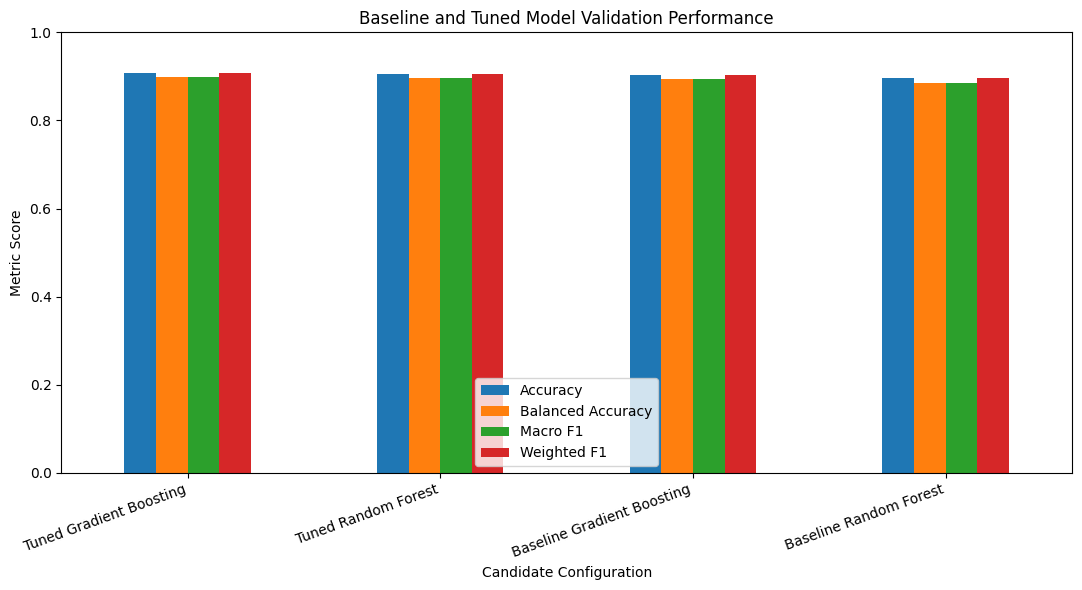

In [92]:
comparison_plot_df = (
    ranked_model_comparison_df[
        [
            "Candidate",
            "Accuracy",
            "Balanced Accuracy",
            "Macro F1",
            "Weighted F1",
        ]
    ]
    .set_index("Candidate")
)

comparison_plot_df.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.title(
    "Baseline and Tuned Model Validation Performance"
)
plt.xlabel("Candidate Configuration")
plt.ylabel("Metric Score")
plt.ylim(0, 1)
plt.xticks(
    rotation=20,
    ha="right",
)
plt.tight_layout()
plt.show()

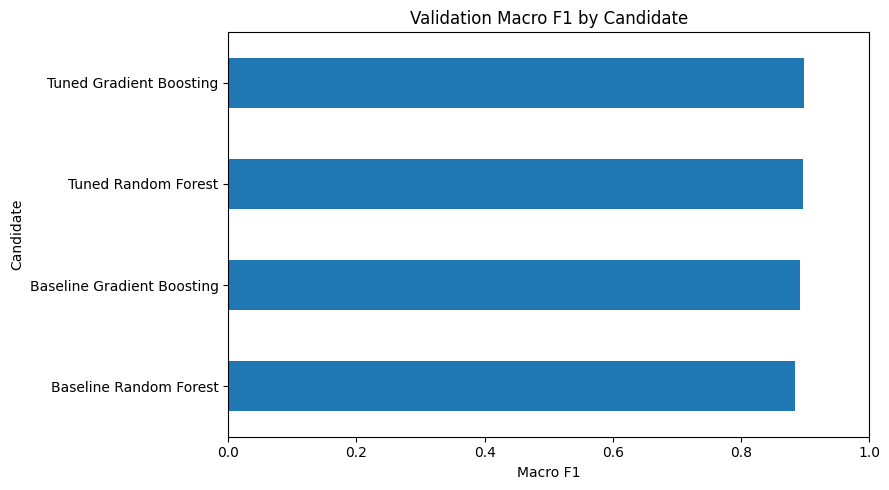

In [93]:
macro_f1_plot_df = (
    ranked_model_comparison_df[
        [
            "Candidate",
            "Macro F1",
        ]
    ]
    .sort_values(
        by="Macro F1",
        ascending=True,
    )
)

macro_f1_plot_df.plot(
    x="Candidate",
    y="Macro F1",
    kind="barh",
    figsize=(9, 5),
    legend=False,
)

plt.title(
    "Validation Macro F1 by Candidate"
)
plt.xlabel("Macro F1")
plt.ylabel("Candidate")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [94]:
print(
    "Best tuned Random Forest parameters:"
)

for key, value in (
    random_forest_best_parameters.items()
):
    print(
        f"{key}: {value}"
    )

print()

print(
    "Best tuned Gradient Boosting parameters:"
)

for key, value in (
    gradient_boosting_best_parameters.items()
):
    print(
        f"{key}: {value}"
    )

Best tuned Random Forest parameters:
classifier__n_estimators: 150
classifier__min_samples_split: 10
classifier__min_samples_leaf: 2
classifier__max_features: 0.5
classifier__max_depth: 20
classifier__class_weight: None

Best tuned Gradient Boosting parameters:
classifier__subsample: 0.8
classifier__n_estimators: 100
classifier__min_samples_split: 5
classifier__min_samples_leaf: 2
classifier__max_features: 0.8
classifier__max_depth: 3
classifier__learning_rate: 0.15


In [95]:
baseline_random_forest_parameters = {
    "n_estimators": 100,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

baseline_gradient_boosting_parameters = {
    "n_estimators": 100,
    "learning_rate": 0.1,
    "max_depth": 3,
    "random_state": RANDOM_STATE,
}

In [96]:
if (
    leading_model_name
    == "Random Forest"
):
    if (
        leading_configuration
        == "Tuned"
    ):
        leading_parameters = (
            random_forest_best_parameters
        )
    else:
        leading_parameters = (
            baseline_random_forest_parameters
        )

elif (
    leading_model_name
    == "Gradient Boosting"
):
    if (
        leading_configuration
        == "Tuned"
    ):
        leading_parameters = (
            gradient_boosting_best_parameters
        )
    else:
        leading_parameters = (
            baseline_gradient_boosting_parameters
        )

else:
    raise ValueError(
        "Unexpected leading model"
    )

leading_parameters

{'classifier__subsample': 0.8,
 'classifier__n_estimators': 100,
 'classifier__min_samples_split': 5,
 'classifier__min_samples_leaf': 2,
 'classifier__max_features': 0.8,
 'classifier__max_depth': 3,
 'classifier__learning_rate': 0.15}

In [97]:
MODEL_TUNING_COMPARISON_PATH = (
    PROJECT_ROOT
    / "reports"
    / "generated"
    / "model_tuning_comparison.csv"
)

ranked_model_comparison_df.to_csv(
    MODEL_TUNING_COMPARISON_PATH,
    index=False,
)

print(
    "Model tuning comparison saved to:",
    MODEL_TUNING_COMPARISON_PATH,
)

Model tuning comparison saved to: C:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\reports\generated\model_tuning_comparison.csv


In [98]:
LEADING_CANDIDATE_PATH = (
    PROJECT_ROOT
    / "reports"
    / "generated"
    / "leading_model_candidate.csv"
)

leading_candidate_df = pd.DataFrame(
    [
        {
            "Model": leading_model_name,
            "Configuration": (
                leading_configuration
            ),
            "Candidate": (
                leading_candidate_name
            ),
            "Validation Macro F1": (
                leading_validation_macro_f1
            ),
            "Validation Accuracy": (
                leading_candidate_row[
                    "Accuracy"
                ]
            ),
            "Validation Balanced Accuracy": (
                leading_candidate_row[
                    "Balanced Accuracy"
                ]
            ),
            "Validation Weighted F1": (
                leading_candidate_row[
                    "Weighted F1"
                ]
            ),
        }
    ]
)

leading_candidate_df.to_csv(
    LEADING_CANDIDATE_PATH,
    index=False,
)

leading_candidate_df.round(4)

,Model,Configuration,Candidate,Validation Macro F1,Validation Accuracy,Validation Balanced Accuracy,Validation Weighted F1
0,Gradient Boosting,Tuned,Tuned Gradient Boosting,0.8978,0.9075,0.8979,0.9071


In [99]:
print(
    "Reserved test feature records:",
    len(X_test),
)

print(
    "Reserved test target records:",
    len(y_test),
)

Reserved test feature records: 3114
Reserved test target records: 3114


In [ ]:
assert len(
    model_tuning_comparison_df
) == 4

assert set(
    model_tuning_comparison_df[
        "Candidate"
    ]
) == {
    "Baseline Random Forest",
    "Tuned Random Forest",
    "Baseline Gradient Boosting",
    "Tuned Gradient Boosting",
}

assert len(
    ranked_model_comparison_df
) == 4

assert (
    ranked_model_comparison_df[
        "Overall Rank"
    ].iloc[0]
    == 1
)

assert len(
    best_family_candidates_df
) == 2

assert leading_model_name in {
    "Random Forest",
    "Gradient Boosting",
}

assert leading_configuration in {
    "Baseline",
    "Tuned",
}

assert (
    0
    <= leading_validation_macro_f1
    <= 1
)

for metric_name in [
    "Accuracy",
    "Balanced Accuracy",
    "Macro F1",
    "Weighted F1",
]:
    assert (
        model_tuning_comparison_df[
            metric_name
        ]
        .between(0, 1)
        .all()
    )

assert (
    MODEL_TUNING_COMPARISON_PATH.exists()
)

assert (
    LEADING_CANDIDATE_PATH.exists()
)

assert len(X_test) == 3114
assert len(y_test) == 3114

Phase 6 Checkpoint 5 validation passed
